# Forecasting Electricity Consumption in Indonesia

## Forecasting Objective

Setelah melakukan analisis eksploratif terhadap konsumsi listrik di Indonesia, langkah selanjutnya adalah melakukan **forecasting** untuk memperkirakan tren konsumsi listrik nasional pada beberapa tahun mendatang.

Forecasting ini bertujuan untuk memberikan gambaran mengenai **potensi perkembangan permintaan listrik di Indonesia** berdasarkan pola historis yang tersedia. Konsumsi listrik sering digunakan sebagai indikator penting dalam menggambarkan perkembangan ekonomi, aktivitas industri, serta pertumbuhan populasi di suatu wilayah.

Dalam analisis ini, digunakan model **ARIMA (AutoRegressive Integrated Moving Average)** yang merupakan salah satu metode time series klasik yang banyak digunakan untuk memodelkan dan memprediksi data runtun waktu berdasarkan pola historisnya.

Dataset yang digunakan merupakan **konsumsi listrik nasional Indonesia dari tahun 2011 hingga 2024**.

## Forecasting Limitations

Model forecasting yang digunakan hanya memanfaatkan pola historis dari data konsumsi listrik. Model ini tidak memasukkan faktor eksternal seperti kebijakan energi, perubahan teknologi, kondisi ekonomi makro, maupun dinamika permintaan energi di sektor industri dan rumah tangga. Oleh karena itu, hasil prediksi sebaiknya diinterpretasikan sebagai indikasi tren potensial, bukan sebagai proyeksi pasti dari konsumsi listrik di masa depan.

In [1]:
# ================== Import Libraries ===============

import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [2]:
# =================== Load Dataset ===================

df = pd.read_csv("../data/processed/listrik_clean.csv")

# Konsumsi listrik nasional per tahun
df_nasional = df[df["provinsi"] == "INDONESIA"][["tahun","listrik_gwh"]]

df_nasional = df_nasional.sort_values("tahun")

**Handling Missing Time Periods**

Dilakukan pemeriksaan kontinuitas periode waktu dan ditemukan adanya tahun yang hilang dalam data. Untuk menjaga konsistensi, rentang tahun dilengkapi dan nilai yang hilang diisi menggunakan **linear interpolation**, yaitu metode yang memperkirakan nilai berdasarkan tren di antara periode sebelum dan sesudahnya agar struktur data tetap terjaga.


In [3]:
# Cek apakah ada tahun yang hilang
print(df_nasional["tahun"].tolist())

[2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


>Tidak ada data untuk tahun 2016

In [4]:
# ============== Handling Missing Time Periods ===============

all_years = pd.DataFrame({
    "tahun": range(df_nasional["tahun"].min(), df_nasional["tahun"].max() + 1)
})

df_nasional = all_years.merge(df_nasional, on="tahun", how="left")

df_nasional["listrik_gwh"] = df_nasional["listrik_gwh"].interpolate()

In [5]:
# ================== Create Time Series ===================

series = df_nasional.set_index("tahun")["listrik_gwh"]

# convert index to datetime
series.index = pd.to_datetime(series.index, format="%Y")

**Stationarity Test (ADF Test)**

Uji **Augmented Dickey-Fuller (ADF)** digunakan untuk mengevaluasi apakah suatu data time series bersifat **stationary** atau tidak. Stationary berarti bahwa statistik dasar seperti mean dan variansi relatif stabil sepanjang waktu.

Hasil pengujian menunjukkan:

* **ADF Statistic:** 0.967
* **p-value:** 0.994

Nilai p-value yang jauh lebih besar dari 0.05 menunjukkan bahwa **data tidak stationary**, sehingga terdapat tren dalam data konsumsi listrik nasional.

Untuk mengatasi hal tersebut, model ARIMA akan menggunakan parameter **d = 1**, yang berarti model akan melakukan **differencing satu kali** untuk membuat data menjadi lebih stationary sebelum dilakukan pemodelan.

In [6]:
# =============== Stationarity Test (ADF Test) ===============

result = adfuller(series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.9672021648624457
p-value: 0.9939075516960979


In [7]:
# ============== Walk Forward Validation ===============

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

history = list(train)

predictions = []

for t in range(len(test)):
    
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    
    forecast = model_fit.forecast()[0]
    
    predictions.append(forecast)
    
    history.append(test.iloc[t])


# evaluation metrics
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 7695.124558328011
RMSE: 7846.363586185249


d:\Data_analyst\electricity_consumption\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Data_analyst\electricity_consumption\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


**Model Evaluation Insight**

Hasil evaluasi menggunakan walk-forward validation menunjukkan bahwa model ARIMA mampu mengikuti tren konsumsi listrik nasional dengan cukup baik. Berdasarkan metrik evaluasi, model menghasilkan **MAE sebesar sekitar 7.7 ribu GWh** dan **RMSE sekitar 7.8 ribu GWh**.

Jika dibandingkan dengan tingkat konsumsi listrik nasional pada tahun-tahun terbaru yang berada pada kisaran **270–300 ribu GWh**, tingkat kesalahan model sekitar **2–3% dari nilai aktual**, yang menunjukkan bahwa model mampu menangkap tren historis konsumsi listrik dengan cukup baik.

Selain itu, nilai RMSE yang relatif dekat dengan MAE menunjukkan bahwa kesalahan prediksi model cukup konsisten dan tidak terdapat deviasi ekstrem dalam hasil prediksi.

Namun demikian, karena jumlah observasi time series yang terbatas, hasil evaluasi ini tetap perlu diinterpretasikan secara hati-hati dan lebih tepat digunakan sebagai indikasi awal kemampuan model dalam menangkap tren historis konsumsi listrik.

In [8]:
# ================== Fit ARIMA Model ===================

model = ARIMA(series, order=(1,1,1))

model_fit = model.fit()

d:\Data_analyst\electricity_consumption\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
d:\Data_analyst\electricity_consumption\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
d:\Data_analyst\electricity_consumption\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
d:\Data_analyst\electricity_consumption\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Data_analyst\electricity_consump

In [9]:
# ============ Forecast Future Electricity Consumption ==============

forecast_steps = 6

forecast = model_fit.forecast(steps=forecast_steps)

In [10]:
# ================= Create Forecast DataFrame ==================

last_year = df_nasional["tahun"].max()

future_years = list(range(last_year + 1, last_year + 1 + forecast_steps))

forecast_df = pd.DataFrame({
    "tahun": future_years,
    "listrik_gwh": forecast.values
})

forecast_df

,tahun,listrik_gwh
0,2025,316474.250305
1,2026,326728.901506
2,2027,336983.373606
3,2028,347237.666608
4,2029,357491.780514
5,2030,367745.715329


In [11]:
# ============ Export Hasil Forecast =============

forecast_df.to_csv("../data/processed/forecast.csv", index=False)
print("Hasil forecast berhasil disimpan")

Hasil forecast berhasil disimpan


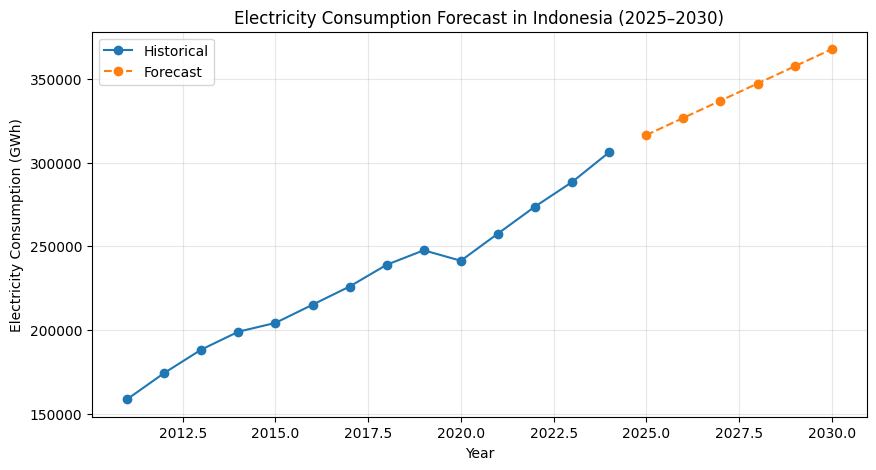

In [12]:
# =============== Plot Historical vs Forecast ===============

plt.figure(figsize=(10,5))

plt.plot(
    df_nasional["tahun"],
    df_nasional["listrik_gwh"],
    marker="o",
    label="Historical"
)

plt.plot(
    forecast_df["tahun"],
    forecast_df["listrik_gwh"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Electricity Consumption Forecast in Indonesia (2025–2030)")

plt.xlabel("Year")
plt.ylabel("Electricity Consumption (GWh)")

plt.grid(alpha=0.3)

plt.legend()

plt.show()


**Forecast Visualization**

Visualisasi dilakukan untuk membandingkan antara:

* Data historis konsumsi listrik (2011–2024)
* Hasil prediksi konsumsi listrik (2025–2030)

Konsumsi listrik diproyeksikan terus meningkat hingga tahun 2030, melanjutkan tren historis tanpa indikasi penurunan, dengan pola pertumbuhan yang relatif stabil dan konsisten serta nilai pada periode prediksi yang melampaui data historis, mengindikasikan peningkatan kebutuhan listrik di masa depan.

In [13]:
# ============== Combine Historical + Forecast =============

combined_df = pd.concat(
    [
        df_nasional[["tahun","listrik_gwh"]],
        forecast_df
    ],
    ignore_index=True
)

combined_df

,tahun,listrik_gwh
0,2011,158694.890000
1,2012,174341.920000
2,2013,188342.410000
3,2014,199028.080000
4,2015,204279.970000
5,2016,215147.015000
6,2017,226014.060000
7,2018,239012.040000
8,2019,247653.330000
9,2020,241405.610000


**Insight**

Hasil forecasting menunjukkan bahwa konsumsi listrik nasional Indonesia diperkirakan akan terus mengalami **tren peningkatan hingga tahun 2030**. Berdasarkan model ARIMA, konsumsi listrik diprediksi meningkat dari sekitar **316 ribu GWh pada tahun 2025** menjadi sekitar **368 ribu GWh pada tahun 2030**.

Peningkatan ini menunjukkan adanya potensi pertumbuhan permintaan energi listrik yang konsisten, yang kemungkinan dipengaruhi oleh faktor seperti **pertumbuhan populasi, ekspansi aktivitas ekonomi, serta peningkatan kebutuhan energi di sektor industri dan rumah tangga**.

Namun demikian, hasil forecasting ini perlu diinterpretasikan secara hati-hati karena model hanya menggunakan data historis dan tidak memasukkan faktor eksternal seperti kebijakan energi, perubahan teknologi, atau kondisi ekonomi di masa depan.
